In [40]:
import joblib
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

from sklearn.datasets import load_digits

In [41]:
iris = load_iris()
X = iris.data
Y= iris.target

In [42]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2 , random_state=52)

In [43]:
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)
y_predicted_knn  = knn.predict(x_test)


In [44]:
print(y_predicted_knn)

[0 0 2 2 2 1 1 0 2 2 2 2 2 0 2 2 0 2 2 0 1 0 1 1 2 2 1 1 2 1]


In [45]:
accuracy_score(y_test,y_predicted_knn)

0.9666666666666667

In [46]:
rfc = RandomForestClassifier(30)
rfc.fit(x_train,y_train)
y_predicted_rfc = rfc.predict(x_test)
print(y_predicted_rfc)
accuracy_score(y_test,y_predicted_rfc)

[0 0 2 2 2 1 1 0 2 2 2 2 2 0 2 2 0 2 2 0 1 0 1 1 2 2 1 1 2 1]


0.9666666666666667

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [48]:
# digits = load_digits()

In [49]:
# print(digits)

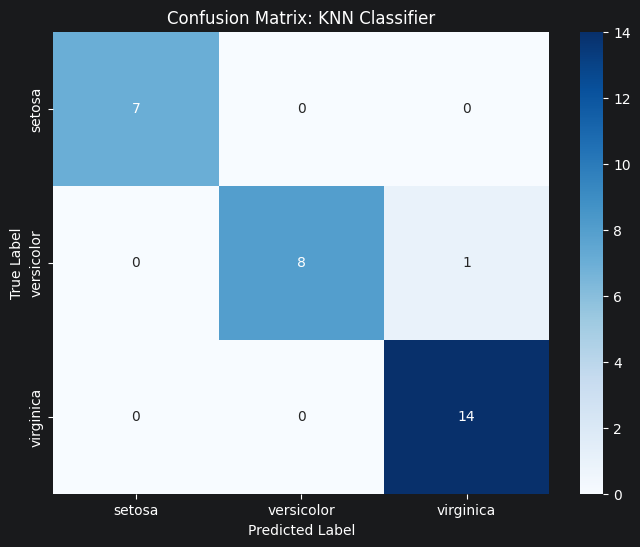

In [50]:
def plot_confusion_matrix(y_true, y_pred, target_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix: KNN Classifier')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

plot_confusion_matrix(y_test, y_predicted_knn, iris.target_names)

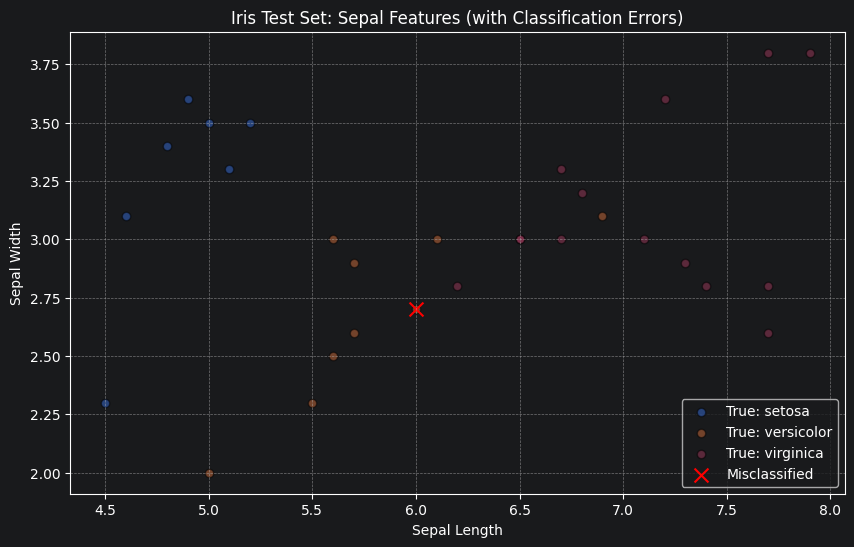

In [51]:
def plot_iris_scatter(X_test, y_true, y_pred, target_names):
    plt.figure(figsize=(10, 6))

    # Plotting based on Sepal Length and Sepal Width (Columns 0 and 1)
    # We use markers to distinguish correct/incorrect predictions
    for i, name in enumerate(target_names):
        # Actual classes
        mask = (y_true == i)
        plt.scatter(X_test[mask, 0], X_test[mask, 1], label=f'True: {name}', alpha=0.5, edgecolors='k')

    # Highlight points where prediction was wrong
    errors = (y_true != y_pred)
    plt.scatter(X_test[errors, 0], X_test[errors, 1], color='red', marker='x', s=100, label='Misclassified')

    plt.title('Iris Test Set: Sepal Features (with Classification Errors)')
    plt.xlabel('Sepal Length')
    plt.ylabel('Sepal Width')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Call the function
plot_iris_scatter(x_test, y_test, y_predicted_knn, iris.target_names)

In [52]:
import joblib
def save_model(model , filename = "iris_Knn_classifier.joblib"):

    joblib.dump(model , filename)
    print("Model Saved")

In [53]:
save_model(knn)

Model Saved


In [54]:
def load_model(filename = "iris_Knn_classifier.joblib"):
    loaded_model = joblib.load(filename)
    return loaded_model